In [104]:
# Imports

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [105]:
# Load dataset

breast_cancer = load_breast_cancer()

X = breast_cancer.data
y = breast_cancer.target

In [106]:
# Split traing and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [107]:
# Pipeline: standardization features and train KNN model

knn_model = Pipeline([
    ("scalar", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=5
    ))
])

knn_model.fit(X_train, y_train)

Pipeline(steps=[('scalar', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [108]:
# Predict using KNN

y_pred = knn_model.predict(X_test)

In [109]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("precession: ", precision_score(y_test, y_pred))
print("recall: ", recall_score(y_test, y_pred))
print("f1 score: ", f1_score(y_test, y_pred))

Accuracy:  0.956140350877193
precession:  0.958904109589041
recall:  0.9722222222222222
f1 score:  0.9655172413793104


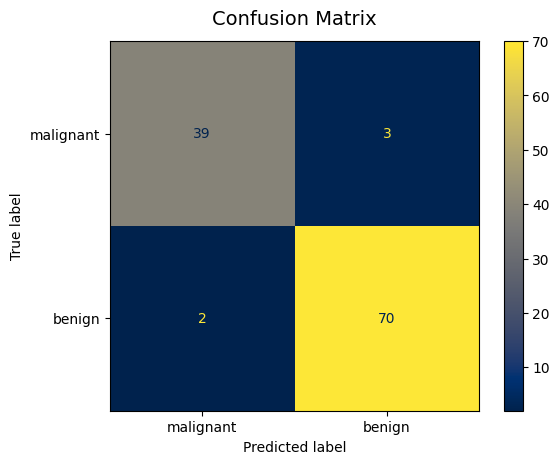

In [110]:
cm = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=breast_cancer.target_names,
    cmap=plt.cm.cividis
)
plt.title("Confusion Matrix", fontsize=14, pad=12)
plt.show()


In [111]:
# Probabiity of positive class

y_prob = knn_model.predict_proba(X_test)[:, 1]

In [112]:
# tpr, fpr and the threshold

fpr, tpr, threshold = roc_curve(y_test, y_prob)

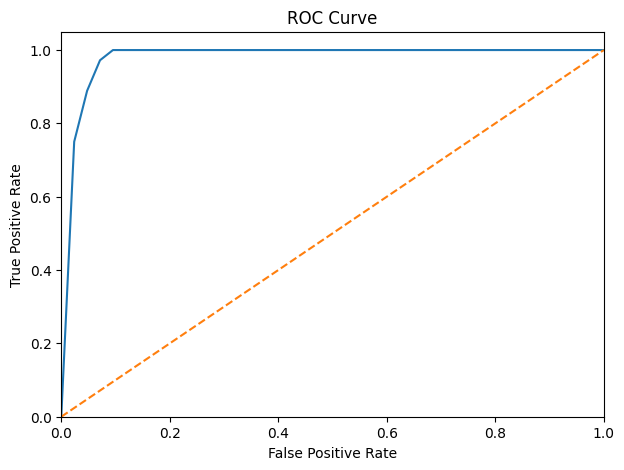

In [113]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [114]:
# Calculate area under the curve

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.9788359788359788


In [115]:
# KNN Cross validation

knn_score = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(f"Scores: {knn_score}")
print(f"Scores mean: {knn_score.mean()}")

Scores: [0.94505495 1.         0.94505495 0.97802198 0.96703297]
Scores mean: 0.9670329670329669
